# Predicting RGC responses to natural images and movies using the spiking models

This notebook generates all the figures for the response prediction results. Before running the notebook, ensure you have fitted all the readout models as outlined in the repository README. Unfortunately, due to size constraints, we were unable to upload all these pre-trained models (and each dimensionality reduced dataset).

In [1]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from retina import analysis

matplotlib.rcParams["svg.fonttype"] = "none"
matplotlib.rcParams["font.family"] = "Arial"

%load_ext autoreload
%autoreload 2

In [2]:
root = os.path.expanduser("~/PycharmProjects/RetinalModel")

## Overview

In [3]:
response_sampler = analysis.ResponseSampler(root, train=True, dataset_name="MarmosetMovie", clip_idx=0, spatial_scale=0.4, max_dim=80.0)

dataset_name=MarmosetMovie pred_ms=64 spatial_scale=0.4 max_dim=80.0


### Sample frames

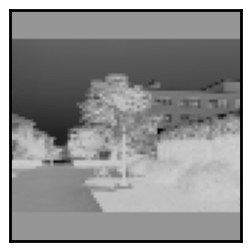

In [4]:
frame = response_sampler.get_clip_frame(-1300)
max_frame_v = frame.abs().max()

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(frame, vmin=-max_frame_v, vmax=max_frame_v, cmap="Greys")
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)

### Real neuron raster 

In [5]:
def plot_raster(x, y, title, ax, s=1):
    ax.scatter(x, y+1, s=1, c="black")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    fs = 24
    ax.xaxis.set_tick_params(width=3, labelsize=int(s*fs), pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=int(s*fs), pad=8)
    ax.set_yticks([1, max(y)+1])
    ax.set_xticks([0, 4320])
    ax.set_xticklabels([])
    ax.set_xlabel("", fontsize=int(s*fs), labelpad=8)
    ax.set_ylabel("Trial", fontsize=int(s*fs), labelpad=2)

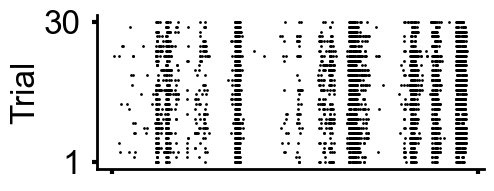

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
x, y = response_sampler.get_neuron_raster(0)
plot_raster(x, y, "", ax)
plt.savefig(f"{root}/figures/fig6/overview_neuron_raster.svg", format="svg", transparent=False, bbox_inches="tight")

### Model unit rasters

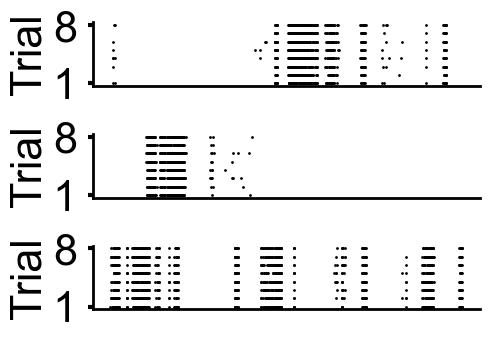

In [7]:
fig, ax = plt.subplots(3, 1, figsize=(5, 3.5))
x1, y1 = response_sampler.get_model_raster(0)
x2, y2 = response_sampler.get_model_raster(33)
x3, y3 = response_sampler.get_model_raster(3)

s = 1.3
plot_raster(x1, y1, "", ax[0], s)
plot_raster(x2, y2, "", ax[1], s)
plot_raster(x3, y3, "", ax[2], s)
ax[0].set_xticks([])
ax[0].set_xlabel("")
ax[1].set_xticks([])
ax[1].set_xlabel("")
ax[2].set_xticks([])
ax[2].set_xlabel("")
fig.tight_layout()
plt.savefig(f"{root}/figures/fig6/overview_model_raster.svg", format="svg", transparent=False, bbox_inches="tight")

### Model PCs

/tmp/ipykernel_817335/412792072.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1716905975447/work/aten/src/ATen/native/TensorShape.cpp:3675.)
  pcs = response_sampler.get_model_pcs().T[:, ::4]


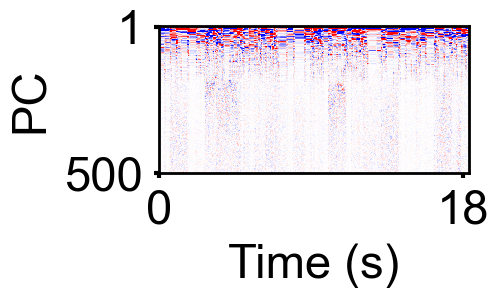

In [8]:
pcs = response_sampler.get_model_pcs().T[:, ::4]
max_pc_v = pcs.abs().max()

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.imshow(pcs, vmin=-1, vmax=1, cmap="bwr")
ax.set_xticks([])
ax.set_yticks([])
ax.spines["top"].set_linewidth(2)
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_linewidth(2)
ax.spines["right"].set_linewidth(2)
fs = 34
ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
ax.set_yticks([0, 500])
ax.set_yticklabels([1, 500])
ax.set_xticks([0, 4320/(1000/240)])
ax.set_xticklabels([0, 18])
ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
ax.set_ylabel("PC", fontsize=fs, labelpad=8)
plt.savefig(f"{root}/figures/fig6/overview_model_pcs.svg", format="svg", transparent=False, bbox_inches="tight")

### Firing rates 

In [9]:
def plot_responses(neuron, model, title, ax):
    ax.plot(neuron, linewidth=4, label="Neuron", color="black")
    ax.plot(model, linewidth=4, label="Model")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    fs = 28
    ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.set_yticks([0, 0.6])
    ax.set_yticklabels([0, int(0.6*240)])
    ax.set_xticks([0, 4320])
    ax.set_xticklabels([0, 18])
    ax.set_xlabel("Time (s)", fontsize=fs, labelpad=8)
    ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=2)
    ax.legend(fontsize=25, loc="upper right", frameon=False)

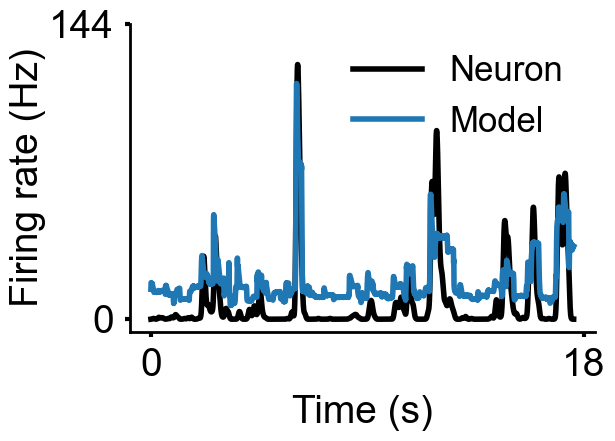

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

neuron_trace = response_sampler.get_neuron_firing_rate(0)
model_trace = response_sampler.get_model_predicted_firing_rate(0)
plot_responses(neuron_trace, model_trace, "", ax)
plt.savefig(f"{root}/figures/fig6/overview_firing_rates.svg", format="svg", transparent=False, bbox_inches="tight")

## CC vs prediction offset

In [11]:
prediction_results = analysis.PredictionResults(root)

dataset_name=MacaqueMovie pred_ms=0 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=8 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=16 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=24 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=32 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=40 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=48 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=56 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=64 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=72 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=80 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=96 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=112 spatial_scale=0.19634 max_dim=20.0
dataset_name=MacaqueMovie pred_ms=128 spatial_scale=0.19634 max_d

In [13]:
def plot_prediction_cc(data_df, title, ax):
    sns.lineplot(data=data_df[data_df["pred_ms"] >= 0], x="pred_ms", y="cc_norm", linewidth=2, errorbar="se", ax=ax)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    fs = 20
    ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.set_ylabel("", fontsize=fs, labelpad=2)
    ax.set_xlabel("Prediction offset (ms)", fontsize=fs, labelpad=8)
    ax.set_title(title, fontsize=fs, pad=24, weight="bold")

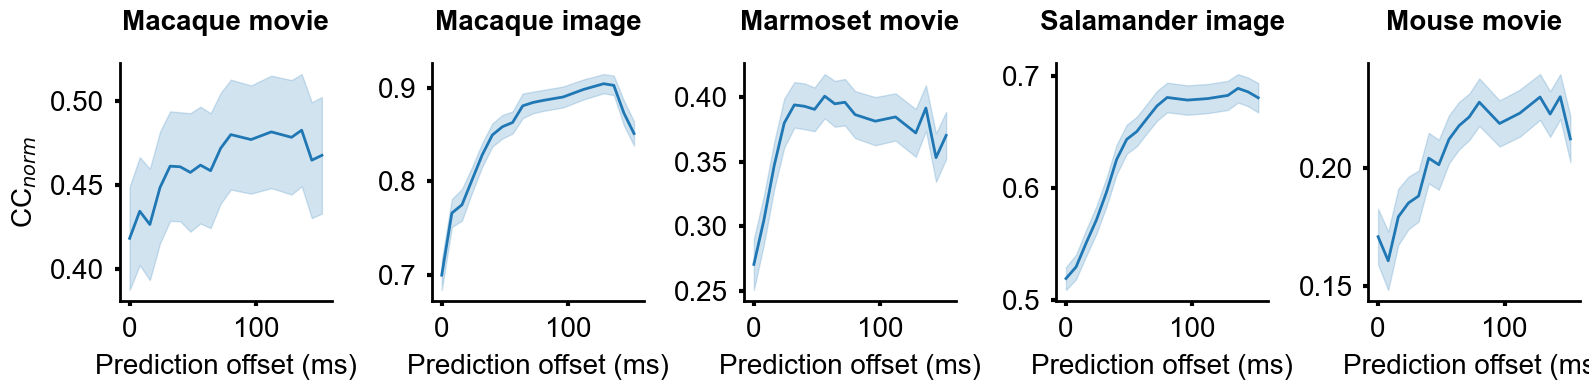

In [14]:
fig, ax = plt.subplots(1, 5, figsize=(16, 4))

plot_prediction_cc(prediction_results.macaque_movie_df, "Macaque movie", ax[0])
plot_prediction_cc(prediction_results.macaque_image_df, "Macaque image", ax[1])
plot_prediction_cc(prediction_results.marmoset_movie_df, "Marmoset movie", ax[2])
plot_prediction_cc(prediction_results.salamander_image_df, "Salamander image", ax[3])
plot_prediction_cc(prediction_results.mouse_movie_df, "Mouse movie", ax[4])
ax[0].set_ylabel("CC$_{norm}$", fontsize=20, labelpad=8)
fig.tight_layout()

## CC of best prediction vs compression model

In [15]:
macaque_movie_best_cc = prediction_results.get_neuron_cc_for_best_model(prediction_results.macaque_movie_df)
macaque_movie_compression_cc = prediction_results.get_neuron_cc_for_compression_model(prediction_results.macaque_movie_df)

macaque_image_best_cc = prediction_results.get_neuron_cc_for_best_model(prediction_results.macaque_image_df)
macaque_image_compression_cc = prediction_results.get_neuron_cc_for_compression_model(prediction_results.macaque_image_df)

marmoset_movie_best_cc = prediction_results.get_neuron_cc_for_best_model(prediction_results.marmoset_movie_df)
marmoset_movie_compression_cc = prediction_results.get_neuron_cc_for_compression_model(prediction_results.marmoset_movie_df)

salamander_image_best_cc = prediction_results.get_neuron_cc_for_best_model(prediction_results.salamander_image_df)
salamander_image_compression_cc = prediction_results.get_neuron_cc_for_compression_model(prediction_results.salamander_image_df)

mouse_movie_best_cc = prediction_results.get_neuron_cc_for_best_model(prediction_results.mouse_movie_df)
mouse_movie_compression_cc = prediction_results.get_neuron_cc_for_compression_model(prediction_results.mouse_movie_df)

In [16]:
prediction_results.best_offsets()

name=macaque_movie offset=136
name=macaque_image offset=128
name=marmoset_movie offset=56
name=salamander_image offset=136
name=mouse_movie offset=144


In [17]:
def plot_compression_vs_best_cc(compression_ccs, best_ccs, title, ax):
    compression_ccs = np.array(compression_ccs)
    best_ccs = np.array(best_ccs)
    
    mean_x = compression_ccs.mean()
    mean_y = best_ccs.mean()
    
    compression_ccs[compression_ccs<0] = 0
    best_ccs[best_ccs<0] = 0
    ax.scatter(compression_ccs, best_ccs, s=40)
    ax.scatter([mean_x], [mean_y], s=40, color="red")
    
    ax.plot([0, 1], [0, 1], "--", color="black", linewidth=2)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    fs = 20
    ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    #ax.set_ylabel("CC (prediction)", fontsize=14, labelpad=2)
    ax.set_xlabel("CCnorm (encoding)", fontsize=fs, labelpad=8)
    #ax.set_title(title, fontsize=20, pad=12)

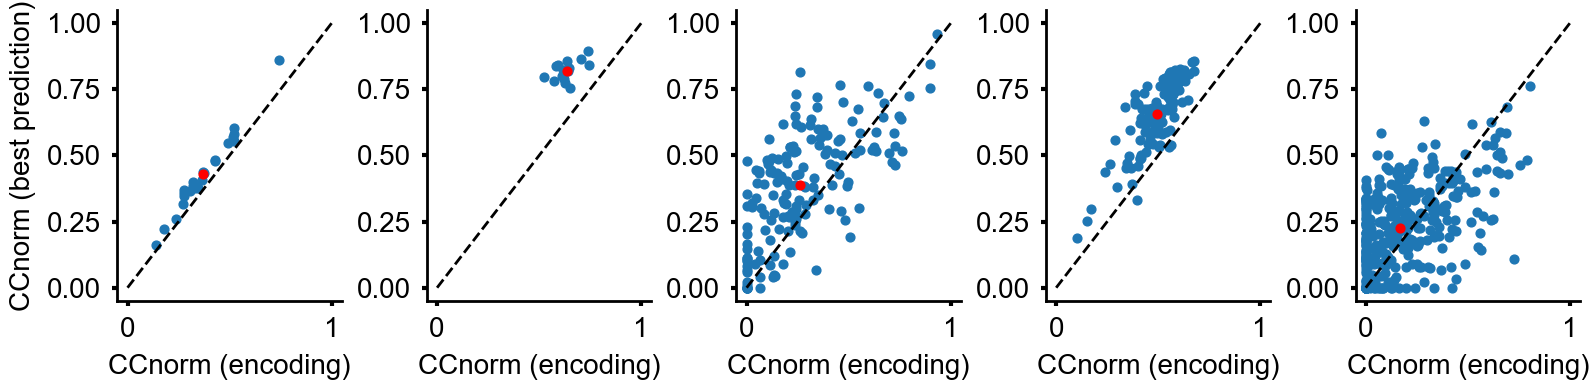

In [18]:
fig, ax = plt.subplots(1, 5, figsize=(16, 4))

plot_compression_vs_best_cc(macaque_movie_compression_cc, macaque_movie_best_cc, "Macaque movie", ax[0])
plot_compression_vs_best_cc(macaque_image_compression_cc, macaque_image_best_cc, "Macaque image", ax[1])
plot_compression_vs_best_cc(marmoset_movie_compression_cc, marmoset_movie_best_cc, "Marmoset movie", ax[2])
plot_compression_vs_best_cc(salamander_image_compression_cc, salamander_image_best_cc, "Salamander image", ax[3])
plot_compression_vs_best_cc(mouse_movie_compression_cc, mouse_movie_best_cc, "Mouse movie", ax[4])
ax[0].set_ylabel("CCnorm (best prediction)", fontsize=20, labelpad=8)
fig.tight_layout()

## Combined

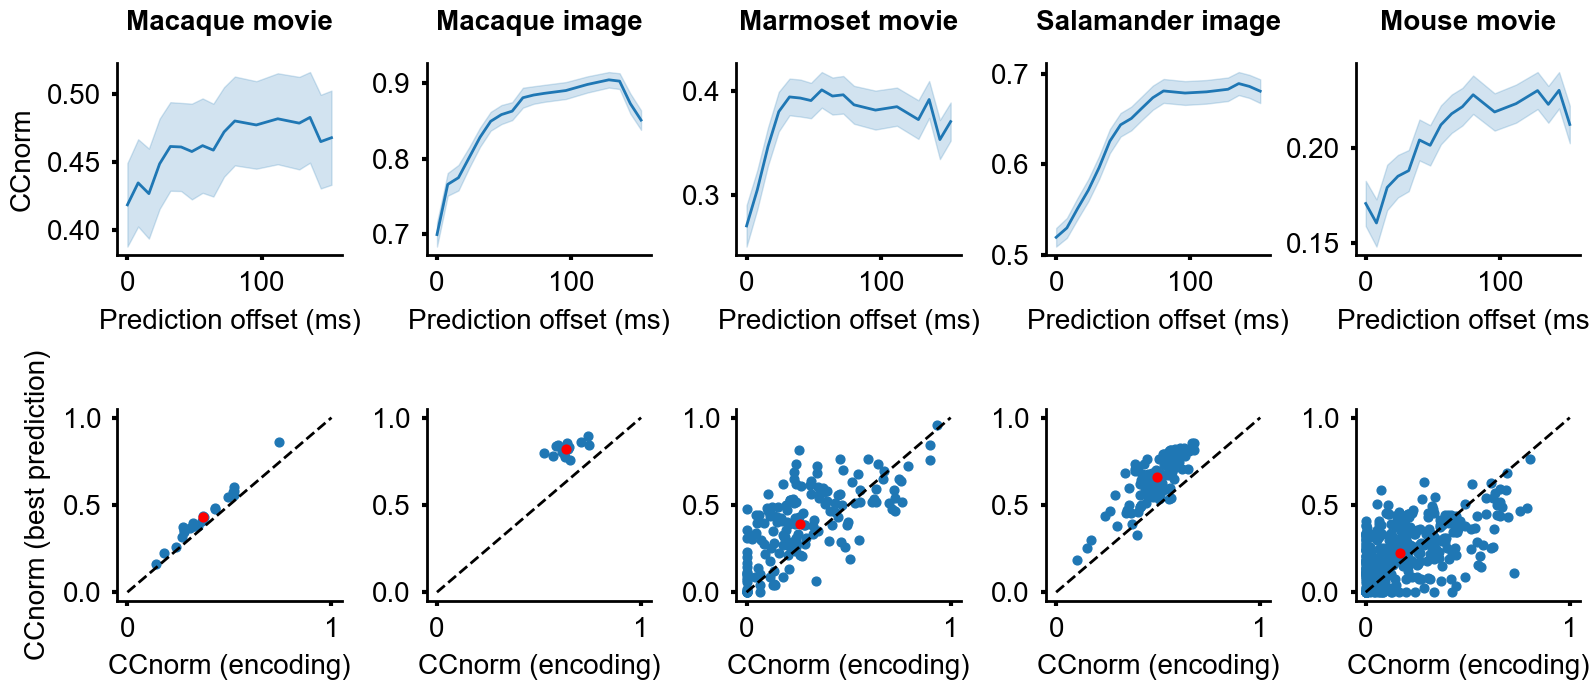

In [18]:
fig, ax = plt.subplots(2, 5, figsize=(16, 7))

plot_prediction_cc(prediction_results.macaque_movie_df, "Macaque movie", ax[0, 0])
plot_prediction_cc(prediction_results.macaque_image_df, "Macaque image", ax[0, 1])
plot_prediction_cc(prediction_results.marmoset_movie_df, "Marmoset movie", ax[0, 2])
plot_prediction_cc(prediction_results.salamander_image_df, "Salamander image", ax[0, 3])
plot_prediction_cc(prediction_results.mouse_movie_df, "Mouse movie", ax[0, 4])
fs = 20
ax[0, 0].set_ylabel("CCnorm", fontsize=fs, labelpad=8)

plot_compression_vs_best_cc(macaque_movie_compression_cc, macaque_movie_best_cc, "Macaque movie", ax[1, 0])
plot_compression_vs_best_cc(macaque_image_compression_cc, macaque_image_best_cc, "Macaque image", ax[1, 1])
plot_compression_vs_best_cc(marmoset_movie_compression_cc, marmoset_movie_best_cc, "Marmoset movie", ax[1, 2])
plot_compression_vs_best_cc(salamander_image_compression_cc, salamander_image_best_cc, "Salamander image", ax[1, 3])
plot_compression_vs_best_cc(mouse_movie_compression_cc, mouse_movie_best_cc, "Mouse movie", ax[1, 4])
ax[1, 0].set_ylabel("CCnorm (best prediction)", fontsize=fs, labelpad=8)
fig.tight_layout()
fig.subplots_adjust(hspace=0.8)
plt.savefig(f"{root}/figures/fig6/combined.svg", format="svg", transparent=False, bbox_inches="tight")

## Predicted traces

In [19]:
enc_marmoset_response_sampler = analysis.ResponseSampler(root, train=False, dataset_name="MarmosetMovie", clip_idx=0, spatial_scale=0.4, max_dim=80.0, toff=0)
pred_marmoset_response_sampler = analysis.ResponseSampler(root, train=False, dataset_name="MarmosetMovie", clip_idx=0, spatial_scale=0.4, max_dim=80.0, toff=64)


dataset_name=MarmosetMovie pred_ms=0 spatial_scale=0.4 max_dim=80.0
dataset_name=MarmosetMovie pred_ms=64 spatial_scale=0.4 max_dim=80.0


In [20]:
enc_mouse_response_sampler = analysis.ResponseSampler(root, train=False, dataset_name="MouseMovie", clip_idx=0, spatial_scale=0.4, max_dim=80.0, toff=0, rf_len_ms=46)
pred_mouse_response_sampler = analysis.ResponseSampler(root, train=False, dataset_name="MouseMovie", clip_idx=0, spatial_scale=0.4, max_dim=80.0, toff=128, rf_len_ms=46)

dataset_name=MouseMovie pred_ms=0 spatial_scale=0.4 max_dim=80.0
dataset_name=MouseMovie pred_ms=128 spatial_scale=0.4 max_dim=80.0


In [21]:
def plot_predicted_responses(neuron, enc_model, pred_model, title, max_x_tick, max_x_label, max_y_tick, ax):
    ax.plot(neuron, linewidth=4, c="black", label="Neuron")
    ax.plot(pred_model, linewidth=6, label="Prediction model")
    ax.plot(enc_model, linewidth=6, label="Encoding model")
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    fs = 28
    ax.xaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.yaxis.set_tick_params(width=3, labelsize=fs, pad=8)
    ax.set_xlabel("")
    ax.set_ylabel("Firing rate (Hz)", fontsize=fs, labelpad=2)
    
    ax.set_yticks([0, max_y_tick])
    ax.set_yticklabels([0, int(max_y_tick*240)])
    ax.set_xticks([0, max_x_tick])
    ax.set_xlim([0, max_x_tick])
    ax.set_xticklabels([0, max_x_label])
    ax.set_title(title, fontsize=fs, pad=20+24, weight="bold")

In [22]:
marmoset_neuron_idx = torch.Tensor(marmoset_movie_best_cc).sort().indices[-21]
marmoset_neuron_fr = enc_marmoset_response_sampler.get_neuron_firing_rate(marmoset_neuron_idx)
marmoset_enc_fr = enc_marmoset_response_sampler.get_model_predicted_firing_rate(marmoset_neuron_idx)
marmoset_pred_fr = pred_marmoset_response_sampler.get_model_predicted_firing_rate(marmoset_neuron_idx)

In [24]:
mouse_neuron_idx = torch.Tensor(mouse_movie_best_cc).sort().indices[-15]
mouse_neuron_fr = enc_mouse_response_sampler.get_neuron_firing_rate(mouse_neuron_idx)
mouse_enc_fr = enc_mouse_response_sampler.get_model_predicted_firing_rate(mouse_neuron_idx)
mouse_pred_fr = pred_mouse_response_sampler.get_model_predicted_firing_rate(mouse_neuron_idx)

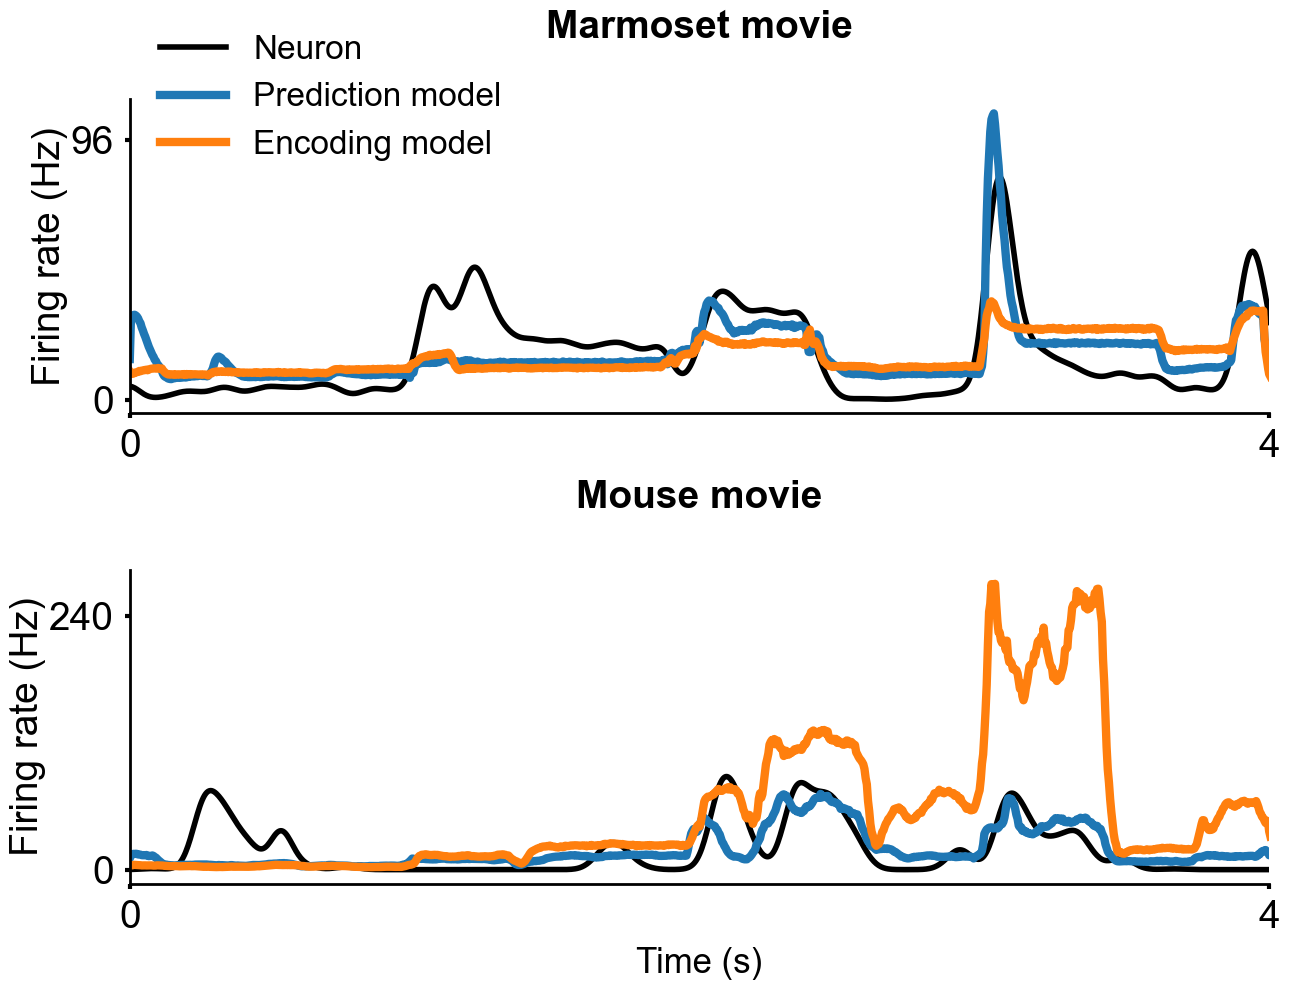

In [25]:
fig, axs = plt.subplots(2, 1, figsize=(13, 10))
plot_predicted_responses(marmoset_neuron_fr, marmoset_enc_fr, marmoset_pred_fr, "Marmoset movie", max_x_tick=960, max_x_label=4, max_y_tick=0.4, ax=axs[0])
plot_predicted_responses(mouse_neuron_fr, mouse_enc_fr, mouse_pred_fr, "Mouse movie", max_x_tick=960, max_x_label=4, max_y_tick=1.0, ax=axs[1])
axs[0].legend(bbox_to_anchor=(0, 1.3), loc="upper left", fontsize=24, frameon=False)
axs[1].set_xlabel("Time (s)", fontsize=25, labelpad=8)
fig.tight_layout()
plt.savefig(f"{root}/figures/fig6/pred_traces.svg", format="svg", transparent=False, bbox_inches="tight")